## 
Plots 
North America extRemes analysis on AFI

'Loc & scale: time':  location.fun= ~ glost, scale.fun = ~glost <br>

In [2]:
import os

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
from copy import copy


In [4]:
from matplotlib import cm

In [5]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [6]:
import warnings
warnings.filterwarnings('ignore')


# READ FILES

In [ ]:
yearb=1941
yeare=2025
B=1000

ifile=f'NorthAmerica_ij_glost_extremes_gev_052026_1941_2025.nc'

dso = xr.open_dataset(ifile)
location = dso['location']
scale = dso['scale']
shape = dso['shape']
rl = dso['rl']
pvalueL = dso['pvalueL']
pvalueS = dso['pvalueS']

Tlon = dso.lon.data
Tlat = dso.lat.data

units = 'degree-days (°C)'


In [8]:
import cmaps
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib as mpl

# Define colors (names, hex codes, or RGB tuples)
B_colors =["xkcd:purpley","darkblue","blue","xkcd:electric blue","xkcd:lightish blue",\
           "xkcd:sky blue","xkcd:baby blue","xkcd:powder blue","aliceblue"]
# Create a smooth gradient colormap
Blues_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", B_colors)

# Define colors (names, hex codes, or RGB tuples)
R_colors = ["lightyellow","xkcd:cream","yellow","gold",  "darkorange","xkcd:blood orange",\
            "xkcd:red","darkred","xkcd:peachy pink"]
# Create a smooth gradient colormap
Reds_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", R_colors)
BR_map = ListedColormap(np.vstack((Blues_map.resampled(128)(np.linspace(0, 1, 128)),Reds_map.resampled(128)(np.linspace(0, 1, 128)))))

I_colors = ['green','yellow','red','pink']
I_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", I_colors)


In [32]:
return_periods = [2, 5, 10, 20, 50, 100]
lon_minC = 235
lon_maxC = 293
lat_minC = 25
lat_maxC = 50
clevsC = np.arange(0,2800,200),

lon_minA = 190
lon_maxA = 220
lat_minA = 52
lat_maxA = 72
clevsA = np.arange(0,6000,500)

In [48]:
Tyears=[1950,1960,1970,1980,1990,2000,2010,2020,2025]
Tyears=[1941,2025]
AEP = [1/irp for irp in return_periods]

In [124]:
latN = 72
latS = 25
lonW = -155+360
lonE = -60+360

cLat = (latN + latS)/2
cLon = (lonW + lonE )/2

Text(0.5, 0.98, '2-year Return Level or 50% AEP level')

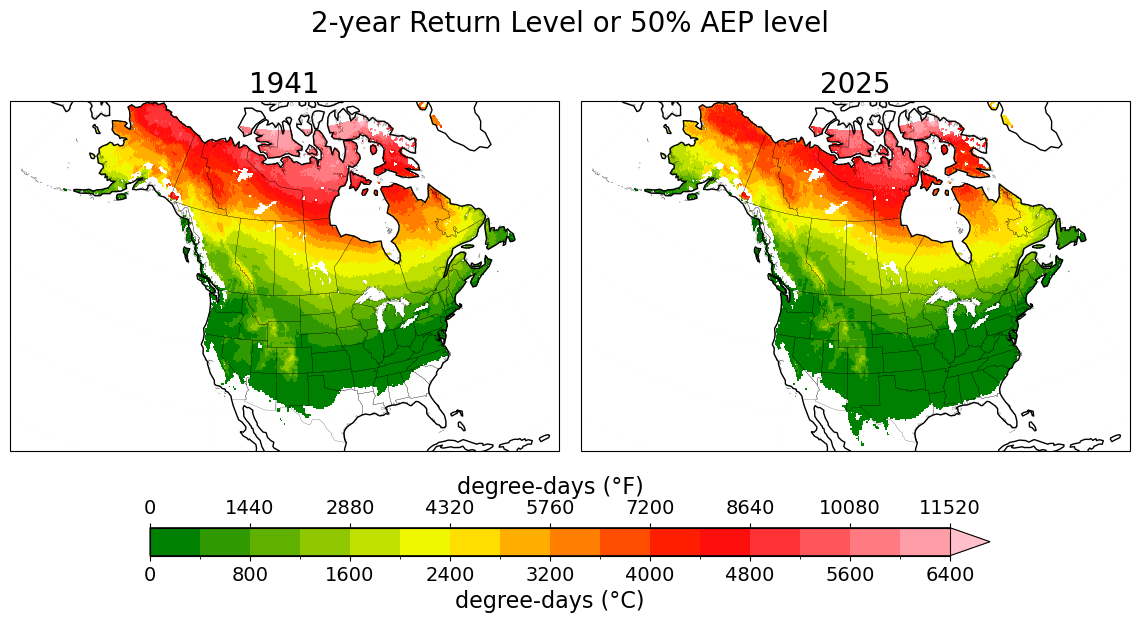

In [144]:
Tyears=[1941,2025]
proj=ccrs.PlateCarree()
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(0,6800,400)
cmap=I_map
irp=0

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7),subplot_kw={'projection':proj})

plt.subplots_adjust(bottom=0.3,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tyears)):
  cc = rl.isel(return_periods=irp).sel(time=Tyears[ix]).\
    plot.pcolormesh(ax=ax[ix],cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
  ax[ix].set_title(f'{Tyears[ix]}',fontsize=20)  
##
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].set_extent((lonW,lonE,latS,latN), crs=proj_data)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])

cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)
# create a second axes instance and set the limits you need
cax2 = cbar.ax.twiny()
cax2.set_xlim(cbar.ax.get_xlim()) 
cax2.set_xlabel('degree-days (°F)',fontsize=16)
# move ticks and label of colorbar to the left
c_ticks = cbar.ax.get_xticks()
cax2.set_xticks(c_ticks)
cax2.set_xticklabels([f'{t*1.8:.0f}' for t in c_ticks],fontsize=14)



plt.suptitle(f'2-year Return Level or 50% AEP level',fontsize=20)  

Text(0.5, 0.98, '2-year Return Level or 50% AEP level')

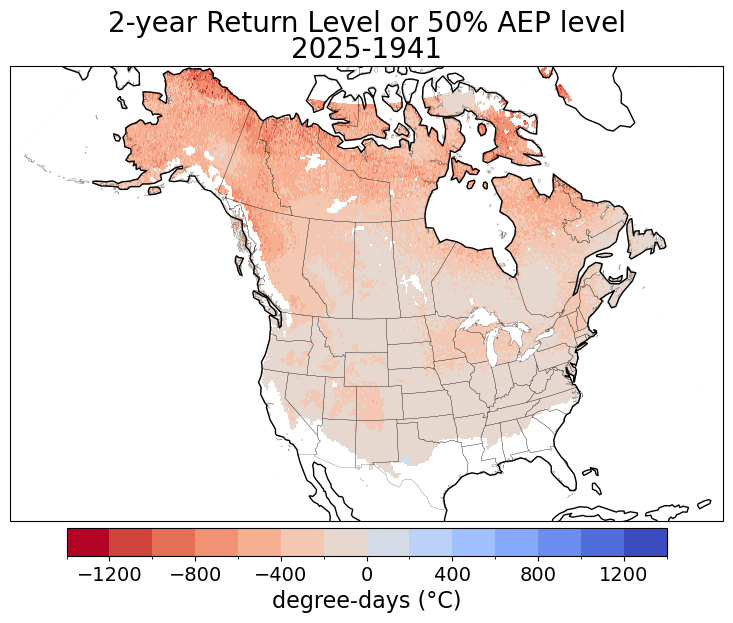

In [138]:

proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(-1400,1600,200)
cmap=cm.coolwarm_r
norm = colors.TwoSlopeNorm(vmin=-600, vcenter=0, vmax=100)
irp=0

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)

cc = (rl.isel(return_periods=irp).sel(time=Tyears[-1])-rl.isel(return_periods=irp).sel(time=Tyears[0])).\
    plot.pcolormesh(ax=ax,transform=ccrs.PlateCarree(),cmap=cmap,levels=clevs,vmin=clevs[0],vmax=-clevs[0],add_colorbar=False)
ax.set_title(f'{Tyears[-1]}-{Tyears[0]}',fontsize=20)  
##

####
grd = ax.gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
grd.top_labels = False   # Disable top labels
grd.right_labels = False # Disable right labels. 
ax.set_extent((lonW,lonE,latS,latN), crs=proj_data)
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()

#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)

plt.suptitle(f'2-year Return Level or 50% AEP level',fontsize=20)  

Text(0.5, 0.98, '50-year Return Level or 2% AEP level')

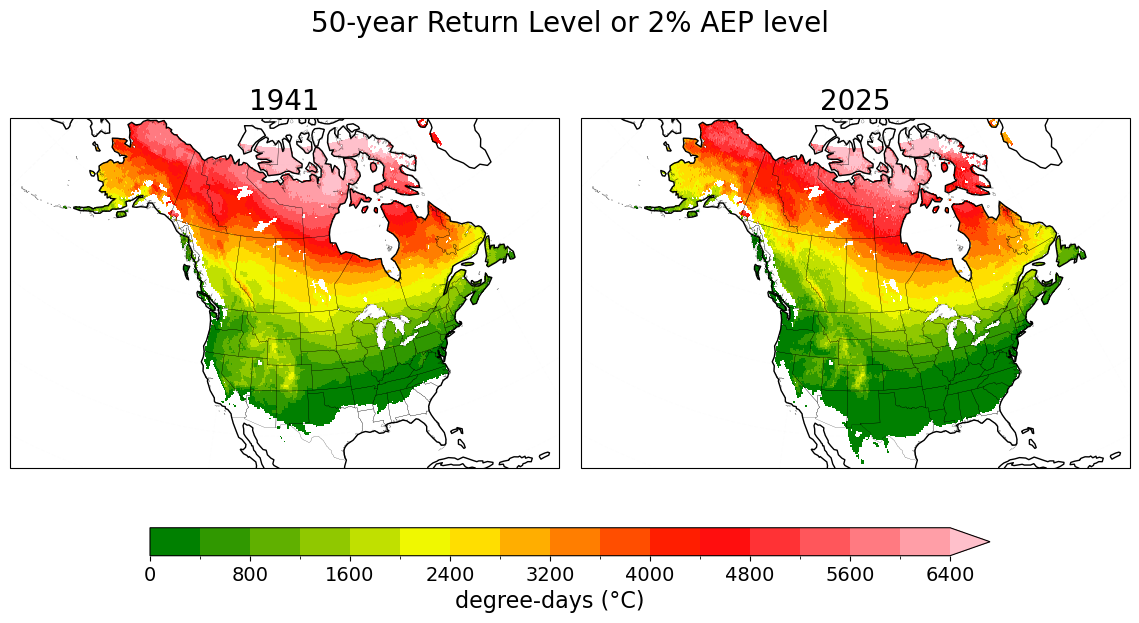

In [135]:
Tyears=[1941,2025]
proj=ccrs.PlateCarree()
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(0,6800,400)
cmap=I_map
irp=4

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7),subplot_kw={'projection':proj})

plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tyears)):
  cc = rl.isel(return_periods=irp).sel(time=Tyears[ix]).\
    plot.pcolormesh(ax=ax[ix],cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
  ax[ix].set_title(f'{Tyears[ix]}',fontsize=20)  
##
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].set_extent((lonW,lonE,latS,latN), crs=proj_data)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])

cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)

plt.suptitle(f'50-year Return Level or 2% AEP level',fontsize=20)  

Text(0.5, 0.98, '50-year Return Level or 2% AEP level')

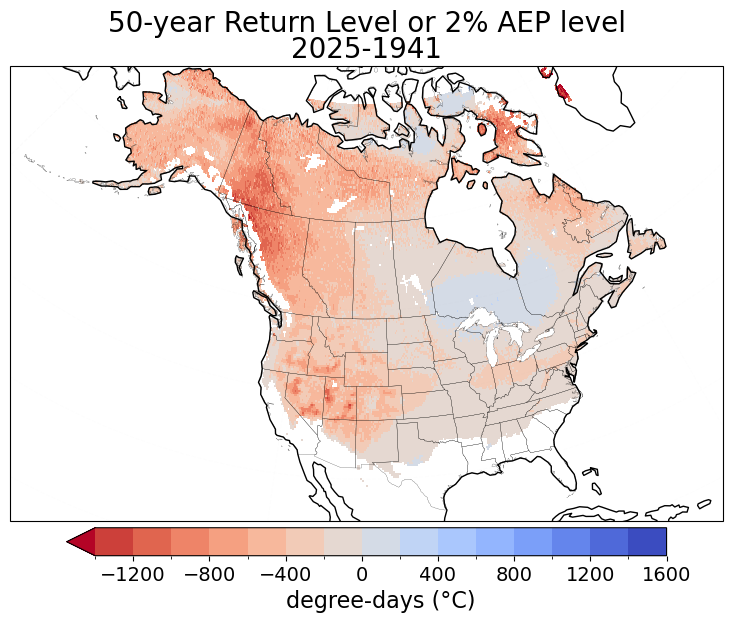

In [136]:

proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(-1400,1800,200)
cmap=cm.coolwarm_r
norm = colors.TwoSlopeNorm(vmin=-600, vcenter=0, vmax=100)
irp=4

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)

cc = (rl.isel(return_periods=irp).sel(time=Tyears[-1])-rl.isel(return_periods=irp).sel(time=Tyears[0])).\
    plot.pcolormesh(ax=ax,transform=ccrs.PlateCarree(),cmap=cmap,levels=clevs,vmin=clevs[0],vmax=-clevs[0],add_colorbar=False)
ax.set_title(f'{Tyears[-1]}-{Tyears[0]}',fontsize=20)  
##

####
grd = ax.gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
grd.top_labels = False   # Disable top labels
grd.right_labels = False # Disable right labels. 
ax.set_extent((lonW,lonE,latS,latN), crs=proj_data)
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()

#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)

plt.suptitle(f'50-year Return Level or 2% AEP level',fontsize=20)  

In [169]:
np.arange(0,6800,400)

array([   0,  400,  800, 1200, 1600, 2000, 2400, 2800, 3200, 3600, 4000,
       4400, 4800, 5200, 5600, 6000, 6400])

Text(0.5, 0.98, '100-year Return Level or 1% AEP level')

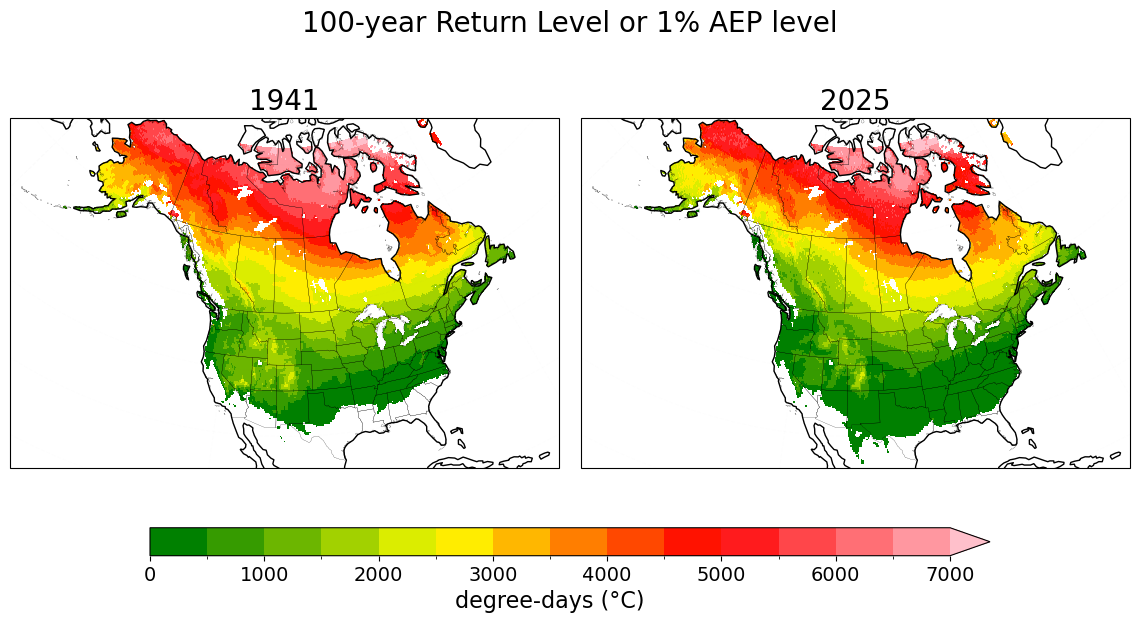

In [171]:
Tyears=[1941,2025]
proj=ccrs.PlateCarree()
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(0,7500,500)
cmap=I_map
irp=5

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7),subplot_kw={'projection':proj})

plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tyears)):
  cc = rl.isel(return_periods=irp).sel(time=Tyears[ix]).\
    plot.pcolormesh(ax=ax[ix],cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
  ax[ix].set_title(f'{Tyears[ix]}',fontsize=20)  
##
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].set_extent((lonW,lonE,latS,latN), crs=proj_data)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])

cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)

plt.suptitle(f'100-year Return Level or 1% AEP level',fontsize=20)  

Text(0.5, 0.98, '100-year Return Level or 1% AEP level')

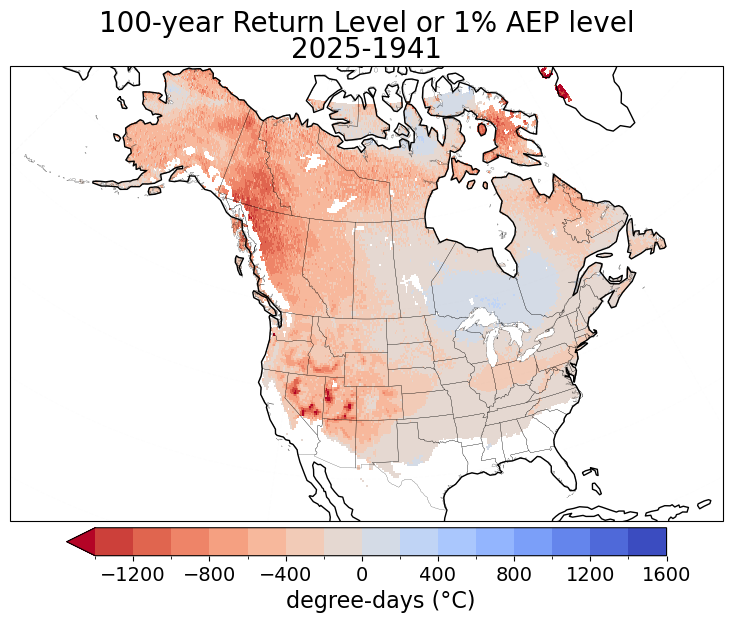

In [133]:

proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(-1400,1800,200)
cmap=cm.coolwarm_r
norm = colors.TwoSlopeNorm(vmin=-600, vcenter=0, vmax=100)
irp=5

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)

cc = (rl.isel(return_periods=irp).sel(time=Tyears[-1])-rl.isel(return_periods=irp).sel(time=Tyears[0])).\
    plot.pcolormesh(ax=ax,transform=ccrs.PlateCarree(),cmap=cmap,levels=clevs,vmin=clevs[0],vmax=-clevs[0],add_colorbar=False)
ax.set_title(f'{Tyears[-1]}-{Tyears[0]}',fontsize=20)  
##

####
grd = ax.gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
grd.top_labels = False   # Disable top labels
grd.right_labels = False # Disable right labels. 
ax.set_extent((lonW,lonE,latS,latN), crs=proj_data)
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()

#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)

plt.suptitle(f'100-year Return Level or 1% AEP level',fontsize=20)  

In [92]:

## Build colorbar
from matplotlib import cm
clevsa=np.arange(0.06,1.01,0.01)
clevsb=np.arange(0,0.051,0.001)
clevs_pv=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('Purples',len(clevsa)+20)
cmaplist = [cmap(i) for i in range(20,cmap.N)]
cmap2 = cm.get_cmap('YlGn_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(0,cmap2.N-5)]

pvalue_cmap = colors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

Text(0.5, 0.98, 'p-value Non Stationnary hypothesis')

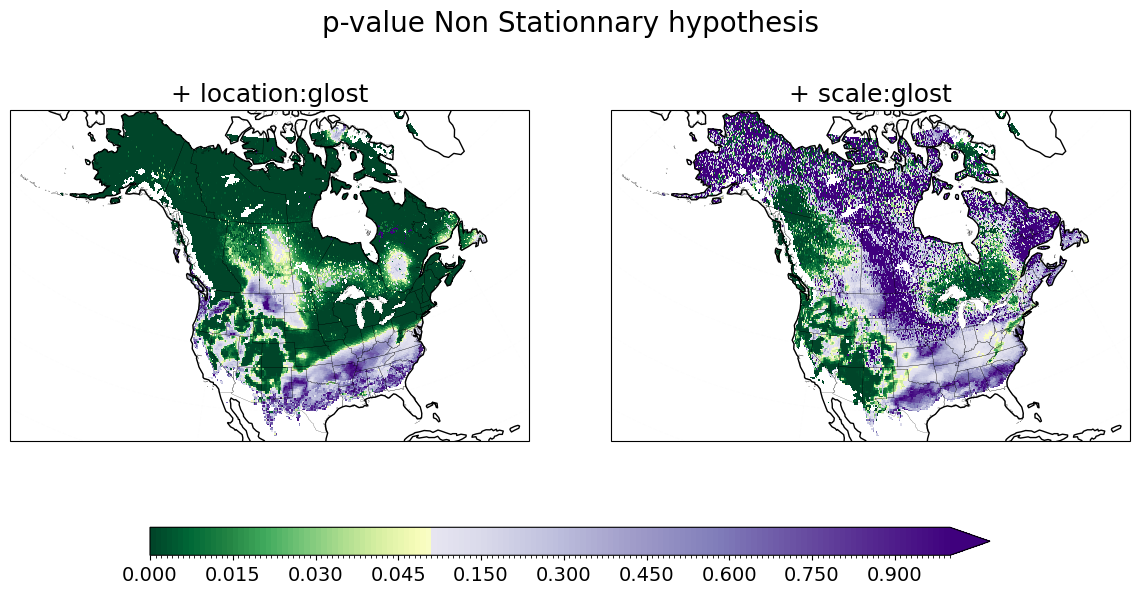

In [172]:
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.95,hspace=0.04,wspace=0.16)
ax = ax.flatten()
cc = pvalueL.plot.pcolormesh(ax=ax[0],cmap=pvalue_cmap,levels=clevs_pv,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[0].set_title(f'+ location:glost',fontsize=18)  
cc = pvalueS.plot.pcolormesh(ax=ax[1],cmap=pvalue_cmap,levels=clevs_pv,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[1].set_title(f'+ scale:glost',fontsize=18)  

for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].set_extent((lonW,lonE,latS,latN), crs=proj_data)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)
#

plt.suptitle(f'p-value Non Stationnary hypothesis',fontsize=20)  

Text(0.5, 0.98, 'Location parameter')

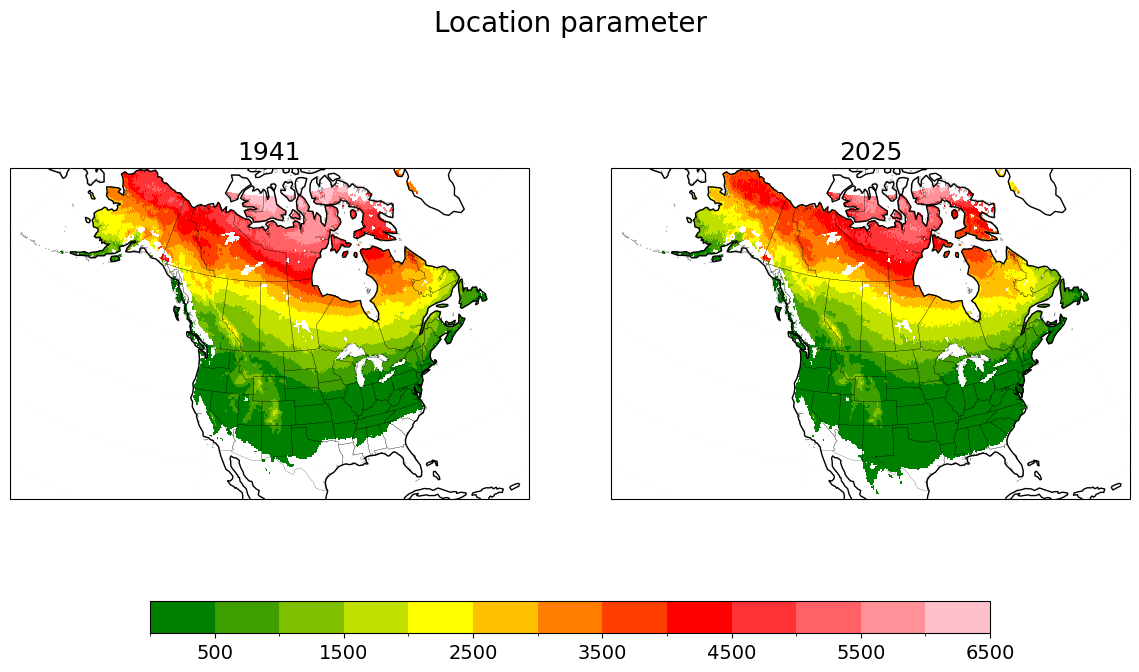

In [167]:
clevs = np.arange(0,7000,500)
cmap = plt.get_cmap(I_map,len(clevs)).copy()

proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = location.sel(time=yearb).plot.pcolormesh(ax=ax[0],cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[0].set_title(yearb,fontsize=18)    
location.sel(time=yeare).plot.pcolormesh(ax=ax[1],cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[1].set_title(yeare,fontsize=18)    

####
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].set_extent((lonW,lonE,latS,latN), crs=proj_data)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[1::2])
cbar.set_label(label='',fontsize=16)
cbar.ax.tick_params(labelsize=14)  
plt.suptitle(f'Location parameter',fontsize=20)  

Text(0.5, 0.98, 'Scale parameter')

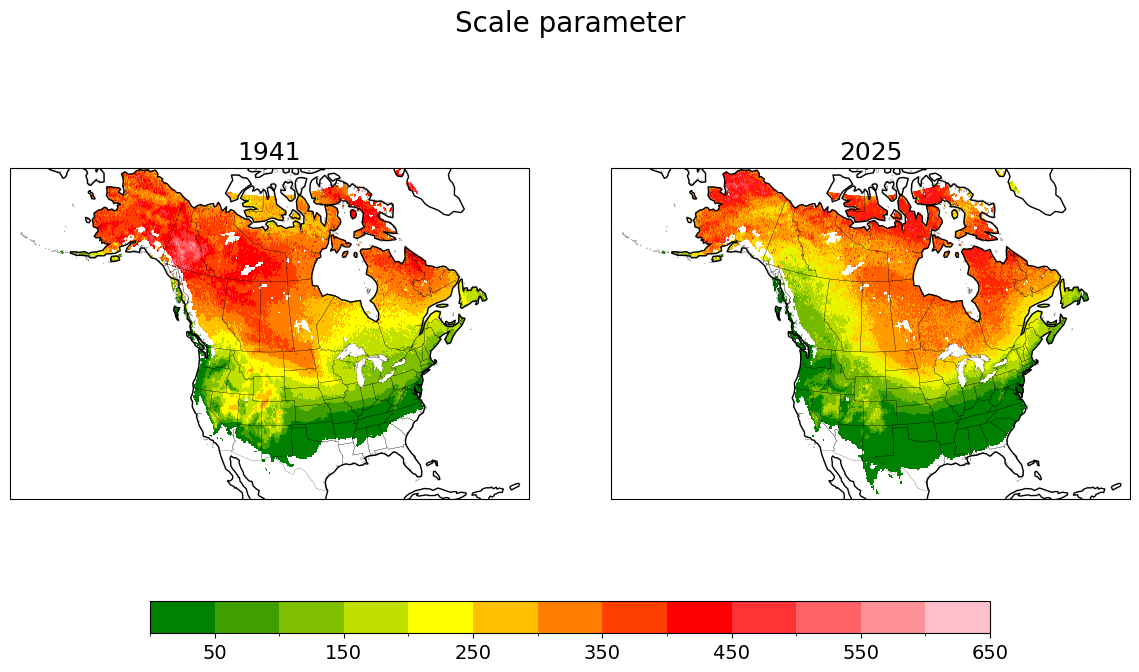

In [163]:
clevs = np.arange(0,700,50)
cmap = plt.get_cmap(I_map,len(clevs)).copy()

proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = scale.sel(time=yearb).plot.pcolormesh(ax=ax[0],cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[0].set_title(yearb,fontsize=18)    
scale.sel(time=yeare).plot.pcolormesh(ax=ax[1],cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[1].set_title(yeare,fontsize=18)    

####
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].set_extent((lonW,lonE,latS,latN), crs=proj_data)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[1::2])
cbar.set_label(label='',fontsize=16)
cbar.ax.tick_params(labelsize=14)  
plt.suptitle(f'Scale parameter',fontsize=20)  

Text(0.5, 0.98, 'Shape parameter')

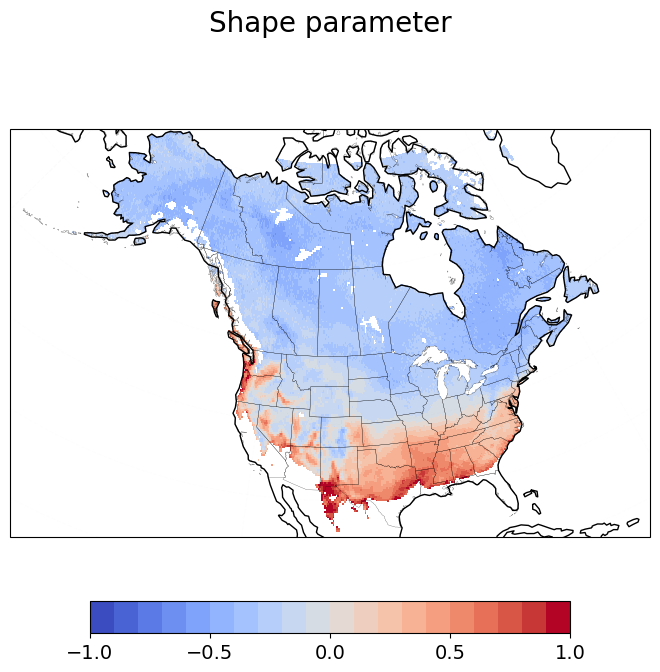

In [157]:
clevs = np.arange(-1,1.1,0.1)
cmap = plt.get_cmap('coolwarm',len(clevs)-1).copy()

proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(8,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = shape.sel(time=yeare).plot.pcolormesh(ax=ax,cmap=cmap,vmin=clevs[0],vmax=clevs[-1],transform=ccrs.PlateCarree(),add_colorbar=False)
ax.set_title('',fontsize=18) 
####

####
grd = ax.gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
grd.top_labels = False   # Disable top labels
grd.right_labels = False # Disable right labels. 
ax.set_extent((lonW,lonE,latS,latN), crs=proj_data)
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()
#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[::5])
cbar.ax.tick_params(labelsize=14)  
plt.suptitle(f'Shape parameter',fontsize=20)  